# Short Stories: NL2P Events vs. Domain PDDL Actions

This notebook compares action extraction from six short stories with independently authored domain PDDLs.

**Comparison levels**

1. **Inventory:** event mentions and unique NL2P verbs vs. reusable PDDL action schemas.
2. **Names:** exact normalized overlap and lightweight lexical correspondence.
3. **Object types:** NL2P argument phrases mapped to PDDL `entity`, `item`, and `location` constants.
4. **Examples:** story excerpts aligned with extracted events and selected PDDL schemas.

> NL2P and PDDL use different units. NL2P records textual event mentions; PDDL defines reusable schemas and may merge several textual events. The results are descriptive, not precision/recall against a gold sequence.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "results/short_stories/domain_comparison").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root")


ROOT = find_repo_root()
RESULT_DIR = ROOT / "results/short_stories/domain_comparison"
STORY_DATA = ROOT / "data/short_stories/mulab_short_stories/selected_stories.json"

summary = pd.read_csv(RESULT_DIR / "summary_by_story.csv")
types = pd.read_csv(RESULT_DIR / "type_distribution.csv")
events = pd.read_csv(RESULT_DIR / "nl2p_event_matches.csv").fillna("")
verbs = pd.read_csv(RESULT_DIR / "nl2p_unique_verbs.csv").fillna("")
pddl_matches = pd.read_csv(RESULT_DIR / "pddl_action_matches.csv").fillna("")
story_payload = json.loads(STORY_DATA.read_text(encoding="utf-8"))
story_texts = {
    record["requested_title"]: record["content"]
    for record in story_payload["stories"]
}

SHORT_NAMES = {
    "Chicken-Licken": "Chicken-Licken",
    "Hansel and Gretel": "Hansel & Gretel",
    "Jack and the Beanstalk": "Jack",
    "The Three Remarks": "Three Remarks",
    "The Three Little Pigs": "Three Pigs",
    "The Four Skillful Brothers": "Four Brothers",
}
COLORS = {"nl2p": "#4472C4", "pddl": "#ED7D31", "neutral": "#70AD47"}
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


def excerpt(title, keyword, radius=420):
    text = " ".join(story_texts[title].split())
    index = text.casefold().find(keyword.casefold())
    if index < 0:
        raise ValueError(f"Keyword {keyword!r} not found in {title!r}")
    start = max(0, index - radius)
    end = min(len(text), index + len(keyword) + radius)
    prefix = "…" if start else ""
    suffix = "…" if end < len(text) else ""
    return prefix + text[start:end].strip() + suffix


def show_excerpt(title, keyword, radius=420):
    display(Markdown(f"> **Source excerpt — {title}**\n>\n> {excerpt(title, keyword, radius)}"))


def event_table(story, *, indices=None, verb_pattern=None):
    frame = events[events["story"].eq(story)].copy()
    if indices is not None:
        frame = frame[frame["event_index"].isin(indices)]
    if verb_pattern is not None:
        frame = frame[frame["nl2p_verb"].str.contains(verb_pattern, case=False, regex=True)]
    return frame[[
        "event_index", "nl2p_verb", "nl2p_arguments",
        "inferred_argument_types", "best_pddl_action", "name_similarity",
    ]]


def pddl_table(story, pattern):
    frame = pddl_matches[
        pddl_matches["story"].eq(story)
        & pddl_matches["pddl_action"].str.contains(pattern, case=False, regex=True)
    ].copy()
    return frame[[
        "pddl_action", "pddl_parameter_types", "best_nl2p_verb",
        "name_similarity", "lexically_linked",
    ]]


## 1. Dataset-level summary

The first view separates three quantities that should not be conflated:

- **NL2P event mentions:** every extracted occurrence in narrative order;
- **NL2P unique verbs:** story-level unique normalized verb labels;
- **PDDL schemas:** reusable domain actions.


story,nl2p_event_mentions,nl2p_unique_verbs,pddl_action_schemas,strict_name_overlap,lexically_linked_nl2p_verbs,lexically_covered_pddl_schemas,argument_type_coverage
Chicken-Licken,22,8,7,2,4,4,100.0%
Hansel and Gretel,75,55,15,0,4,4,53.1%
Jack and the Beanstalk,58,45,12,0,5,4,64.3%
The Three Remarks,55,41,12,0,1,1,50.0%
The Three Little Pigs,45,35,21,0,7,6,58.3%
The Four Skillful Brothers,46,30,21,0,6,5,77.4%


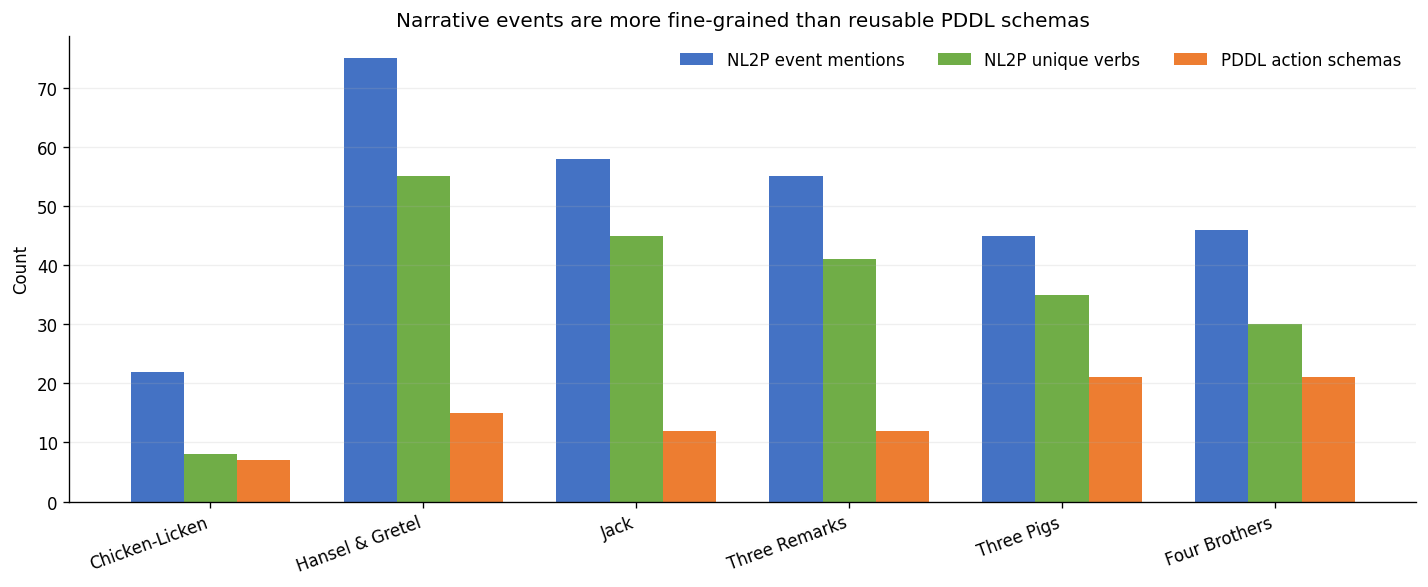

In [2]:
overview = summary[[
    "story", "nl2p_event_mentions", "nl2p_unique_verbs", "pddl_action_schemas",
    "strict_name_overlap", "lexically_linked_nl2p_verbs",
    "lexically_covered_pddl_schemas", "argument_type_coverage",
]].copy()
overview["argument_type_coverage"] = overview["argument_type_coverage"].map(lambda value: f"{value:.1%}")
display(overview.style.hide(axis="index").format(thousands=","))

x = np.arange(len(summary))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, summary["nl2p_event_mentions"], width, label="NL2P event mentions", color="#4472C4")
ax.bar(x, summary["nl2p_unique_verbs"], width, label="NL2P unique verbs", color="#70AD47")
ax.bar(x + width, summary["pddl_action_schemas"], width, label="PDDL action schemas", color="#ED7D31")
ax.set_xticks(x, [SHORT_NAMES[name] for name in summary["story"]], rotation=20, ha="right")
ax.set_ylabel("Count")
ax.set_title("Narrative events are more fine-grained than reusable PDDL schemas")
ax.legend(frameon=False, ncol=3)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### Main observation

Across all stories, NL2P extracts **301 event mentions** and **214 story-level unique verb labels**, while the PDDLs define **88 action schemas**. The gap reflects both repeated narrative events and schema abstraction. Chicken-Licken is the clearest compression case: repeated meetings and turns are represented by only a few reusable actions.


## 2. Action-name correspondence

Exact name overlap is intentionally strict. The lexical view applies basic token normalization and links a pair when token-level F1 is at least 0.5. It is useful for candidate discovery, but still requires semantic review.


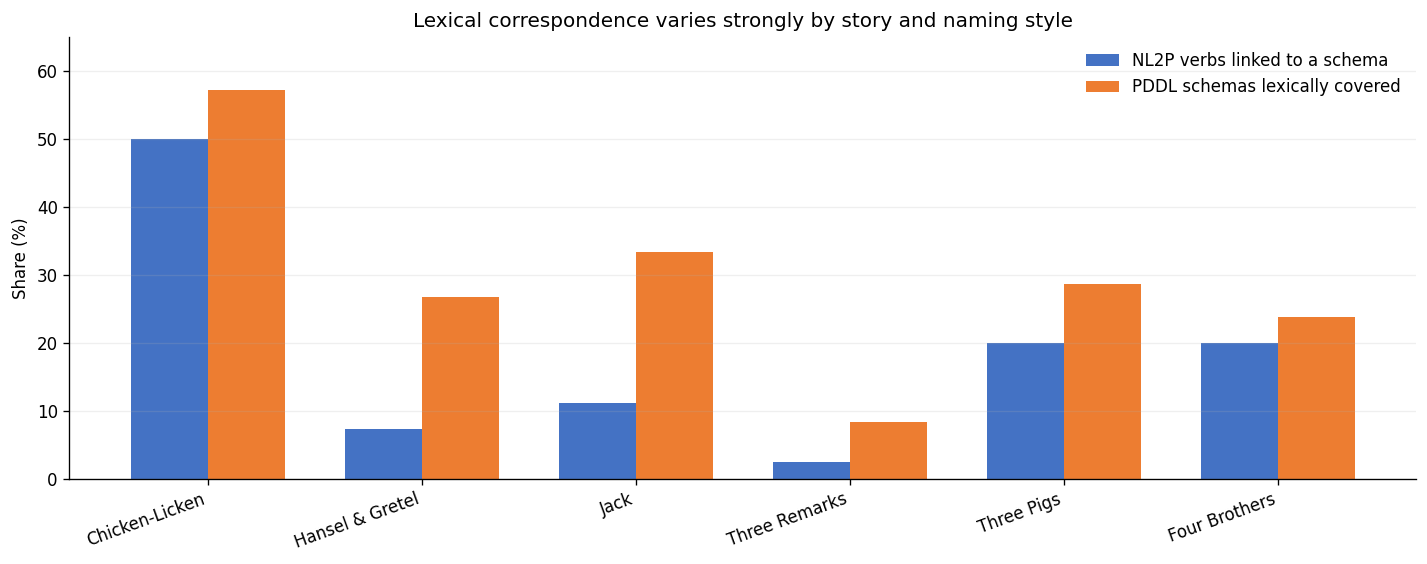

story,pddl_action,best_nl2p_verb,name_similarity,pddl_parameter_types
Chicken-Licken,turn_back,turned back,1.000,entity
Chicken-Licken,meet_character,met,1.000,entity | entity | location
Chicken-Licken,be_eaten_by_fox,ate up,0.667,entity | location
Hansel and Gretel,leave_children_at_fire,left,0.667,entity | entity | entity | entity | location
Hansel and Gretel,enter_witch_house,entered,0.667,entity | entity | location
Hansel and Gretel,push_witch_into_oven,pushed,0.667,entity | entity | item | location
Jack and the Beanstalk,climb_beanstalk,climbed up the beanstalk,0.800,entity
Jack and the Beanstalk,hide_in_kettle,hid,0.667,entity | item
Jack and the Beanstalk,return_down_beanstalk,climbed down the beanstalk,0.667,entity
Jack and the Beanstalk,hide_in_oven,hid,0.667,entity | item


In [3]:
alignment = summary[["story", "nl2p_unique_verbs", "pddl_action_schemas"]].copy()
alignment["Linked NL2P verbs"] = (
    summary["lexically_linked_nl2p_verbs"] / summary["nl2p_unique_verbs"] * 100
)
alignment["Covered PDDL schemas"] = (
    summary["lexically_covered_pddl_schemas"] / summary["pddl_action_schemas"] * 100
)

x = np.arange(len(alignment))
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(x - 0.18, alignment["Linked NL2P verbs"], 0.36, label="NL2P verbs linked to a schema", color="#4472C4")
ax.bar(x + 0.18, alignment["Covered PDDL schemas"], 0.36, label="PDDL schemas lexically covered", color="#ED7D31")
ax.set_xticks(x, [SHORT_NAMES[name] for name in alignment["story"]], rotation=20, ha="right")
ax.set_ylabel("Share (%)")
ax.set_ylim(0, 65)
ax.set_title("Lexical correspondence varies strongly by story and naming style")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

strong = pddl_matches[pddl_matches["name_similarity"].ge(0.65)][[
    "story", "pddl_action", "best_nl2p_verb", "name_similarity", "pddl_parameter_types",
]].sort_values(["story", "name_similarity"], ascending=[True, False])
display(strong.style.hide(axis="index").format({"name_similarity": "{:.3f}"}))


### Interpretation

High-scoring pairs usually share the core event verb, for example `climb_beanstalk` ↔ `climbed up the beanstalk`. Low coverage does not necessarily imply disagreement: schema names frequently encode participants or combine outcomes that are absent from the NL2P verb label.


## 3. Object and parameter types

NL2P has no explicit PDDL type field. Its argument phrases are mapped to story-specific PDDL constants when lexical evidence is available. `unknown` is retained rather than forcing a type.


object_type,nl2p_argument_count,pddl_parameter_count,NL2P share,PDDL share
entity,103,128,32.4%,64.3%
item,70,32,22.0%,16.1%
location,29,39,9.1%,19.6%
unknown,116,0,36.5%,0.0%


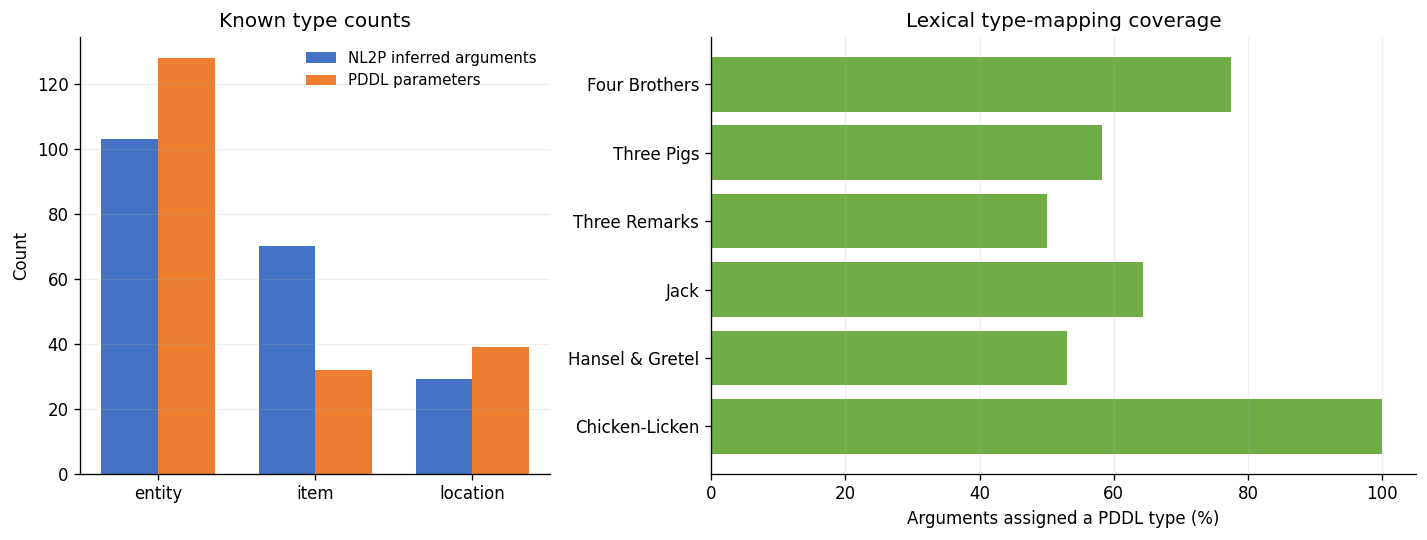

In [4]:
type_totals = types.groupby("object_type", as_index=False)[
    ["nl2p_argument_count", "pddl_parameter_count"]
].sum()
type_totals["NL2P share"] = type_totals["nl2p_argument_count"] / type_totals["nl2p_argument_count"].sum()
type_totals["PDDL share"] = type_totals["pddl_parameter_count"] / type_totals["pddl_parameter_count"].sum()
display(type_totals.style.hide(axis="index").format({"NL2P share": "{:.1%}", "PDDL share": "{:.1%}"}))

known = type_totals[type_totals["object_type"].ne("unknown")]
x = np.arange(len(known))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1, 1.5]})
axes[0].bar(x - 0.18, known["nl2p_argument_count"], 0.36, label="NL2P inferred arguments", color="#4472C4")
axes[0].bar(x + 0.18, known["pddl_parameter_count"], 0.36, label="PDDL parameters", color="#ED7D31")
axes[0].set_xticks(x, known["object_type"])
axes[0].set_ylabel("Count")
axes[0].set_title("Known type counts")
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(axis="y", alpha=0.2)

axes[1].barh(
    [SHORT_NAMES[name] for name in summary["story"]],
    summary["argument_type_coverage"] * 100,
    color="#70AD47",
)
axes[1].set_xlim(0, 105)
axes[1].set_xlabel("Arguments assigned a PDDL type (%)")
axes[1].set_title("Lexical type-mapping coverage")
axes[1].grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


### Type-level reading

Among mapped NL2P arguments, concrete story objects make `item` relatively prominent. PDDL schemas use more `entity` parameters because actor/participant variables are part of reusable action definitions even when the surface event mention omits the agent. The comparison concerns representation choices, not type-classification accuracy.


## 4. Example A — The Three Little Pigs: several events become one schema

The ending illustrates **schema composition**. NL2P keeps preparation, falling, covering, boiling, and eating as separate event mentions. The PDDL combines the causal climax into broader actions and declares the participants required by each schema.


In [5]:
show_excerpt("The Three Little Pigs", "chimney", radius=520)
display(event_table("The Three Little Pigs", indices=range(39, 46)).style.hide(axis="index"))
display(pddl_table("The Three Little Pigs", "chimney|boiling|pot|fire").style.hide(axis="index"))


> **Source excerpt — The Three Little Pigs**
>
> …and ran away home in a fright without ever going to the fair at all. He went to the little pig's house to tell him how frightened he had been by a large round thing which came rolling past him down the hill. "Ha! ha!" laughed the little pig; "so I frightened you, eh? I had been to the fair and bought a butter-churn; when I saw you I got inside it and rolled down the hill." This made the wolf so angry that he declared that he would eat up the little pig, and that nothing should save him, for he would jump down the chimney. But the clever little pig hung a pot full of water over the hearth and then made a blazing fire, and just as the wolf was coming down the chimney he took off the cover and in fell the wolf. In a second the little pig had popped the lid on again. Then he boiled the wolf, and ate him for supper, and after that he lived quietly and comfortably all his days, and was never troubled by a wolf again. CHILDREN'S FAVORITE POEMS

event_index,nl2p_verb,nl2p_arguments,inferred_argument_types,best_pddl_action,name_similarity
39,hung,a pot full of water,item,wolf_promises_turnip_field,0.000000
40,made,a blazing fire,item,wolf_promises_turnip_field,0.000000
41,took off,the cover,unknown,wolf_promises_turnip_field,0.000000
42,fell in,the wolf,entity,wolf_falls_into_pot_and_is_boiled,0.400000
43,popped on again,the lid,unknown,wolf_promises_turnip_field,0.000000
44,boiled,the wolf,entity,wolf_falls_into_pot_and_is_boiled,0.400000
45,ate,the wolf,entity,wolf_eats_pig,1.000000


pddl_action,pddl_parameter_types,best_nl2p_verb,name_similarity,lexically_linked
wolf_attempts_chimney_entry,entity | location,went to the little pig's house,0.000000,False
pig_prepares_boiling_pot_and_fire,entity | item | item | location,boiling,0.400000,False
wolf_falls_into_pot_and_is_boiled,entity | item,fell in,0.400000,False


**Example analysis**

- NL2P preserves the textual sequence: `hung` → `made` → `took off` → `fell in` → `popped on again` → `boiled` → `ate`.
- PDDL abstracts preparation as `pig_prepares_boiling_pot_and_fire(entity, item, item, location)`.
- The climax is compressed into `wolf_falls_into_pot_and_is_boiled(entity, item)`.
- The surface events `fell in` and `boiled` are both components of the second schema, but the simple name matcher scores its best candidate only 0.4 and leaves it unlinked at the 0.5 threshold.
- Even a successful name match could not express that several preceding NL2P events jointly establish the schema preconditions. This is a many-to-one semantic relation.


## 5. Example B — Chicken-Licken: repetition becomes reusable actions

Chicken-Licken repeatedly meets another character, after which that character turns back and joins the group. NL2P records every occurrence; PDDL defines each recurring transition once.


In [6]:
show_excerpt("Chicken-Licken", "Cock-lock", radius=580)
display(event_table("Chicken-Licken", indices=range(3, 18)).style.hide(axis="index"))
display(pddl_table("Chicken-Licken", "meet_character|turn_back|inform_about").style.hide(axis="index"))


> **Source excerpt — Chicken-Licken**
>
> As Chicken-licken was going one day to the wood, whack! an acorn fell from a tree on to his head. "Gracious goodness me!" said Chicken-licken, "the sky must have fallen; I must go and tell the King." So Chicken-licken turned back, and met Hen-len. "Well, Hen-len, where are you going?" said he. "I'm going to the wood," said she. "Oh, Hen-len, don't go!" said he, "for as I was going the sky fell on to my head, and I'm going to tell the King." So Hen-len turned back with Chicken-licken, and met Cock-lock. "I'm going to the wood," said he. Then Hen-len said: "Oh Cock-lock, don't go, for I was going, and I met Chicken-licken, and Chicken-licken had been at the wood, and the sky had fallen on to his head, and we are going to tell the King." So Cock-lock turned back, and they met Duck-luck. "Well, Duck-luck, where are you going?" And Duck-luck said: "I'm going to the wood." Then Cock-lock said: "Oh! Duck-luck, don't go, for I was going, and I met Hen-len, and Hen-len met Chicken-licken, and Chicken-licken had been at the wood, and the sky had fallen on to his head, and we are…

event_index,nl2p_verb,nl2p_arguments,inferred_argument_types,best_pddl_action,name_similarity
3,turned back,Chicken-licken,entity,turn_back,1.000000
4,met,Hen-len,entity,meet_character,1.000000
5,turned back,Hen-len,entity,turn_back,1.000000
6,met,Cock-lock,entity,meet_character,1.000000
7,turned back,Cock-lock,entity,turn_back,1.000000
8,met,Duck-luck,entity,meet_character,1.000000
9,turned back,Duck-luck,entity,turn_back,1.000000
10,met,Drake-lake,entity,meet_character,1.000000
11,turned back,Drake-lake,entity,turn_back,1.000000
12,met,Goose-loose,entity,meet_character,1.000000


pddl_action,pddl_parameter_types,best_nl2p_verb,name_similarity,lexically_linked
turn_back,entity,turned back,1.000000,True
meet_character,entity | entity | location,met,1.000000,True
inform_about_sky_fall,entity | entity,fell,0.400000,False


**Example analysis**

- NL2P extracts repeated `met` and `turned back` mentions for Hen-len, Cock-lock, Duck-luck, and later characters.
- PDDL represents the pattern using `meet_character(entity, entity, location)` and `turn_back(entity)`.
- This explains why 22 NL2P mentions reduce to only seven domain schemas, while also producing the strongest exact/lexical overlap among the six stories.
- The PDDL parameter list is structurally richer: `met` has one explicitly extracted NL2P argument in several sentences, whereas the reusable schema requires two entities and their location.


## 6. Example C — Hansel and Gretel: an omitted event and a lexical false match

The pebble episode exposes a limitation of verb-only matching. The source explicitly describes following the pebble track home, and the PDDL contains that schema, but NL2P does not preserve it as a distinct extracted event.


In [7]:
show_excerpt("Hansel and Gretel", "followed the track", radius=560)
display(event_table("Hansel and Gretel", indices=range(12, 22)).style.hide(axis="index"))
display(pddl_table("Hansel and Gretel", "pebble|breadcrumb").style.hide(axis="index"))


> **Source excerpt — Hansel and Gretel**
>
> …eard was only a dry branch which the man had bound to a tree, so that the wind swung it hither and thither, and the noise it made deceived the children. At last the poor, tired, little eyelids closed, and, side by side, brother and sister fell asleep. When they awoke, the night was very dark, and Gretel was frightened, and began to cry. Hansel put his arms around her and whispered. "Wait, dearie, till the moon rises; we shall soon find our way home then." As soon as the bright moon rose, Hansel took his little sister by the hand, and all night long they followed the track of the little white pebbles, until at daybreak they came to their father's house. They knocked at the door, and no sooner did the stepmother open it than she began to scold them for having stayed out so long in the wood; but the father greeted them kindly, for he had grieved sorely for his little ones. In a short time they were as badly off as ever, and one night they again heard their mother trying to persuade her husband to take them out into the wood and lose them. "There is nothing left in the house but half a loaf of bread," she said; "for our own…

event_index,nl2p_verb,nl2p_arguments,inferred_argument_types,best_pddl_action,name_similarity
12,set out,the father | the stepmother | Hansel | Gretel,unknown | unknown | entity | unknown,wander_forest_seeking_way_out,0.286000
13,dropped,the pebbles,item,witch_captures_children,0.000000
14,gathered,a pile of brushwood and twigs,item,witch_captures_children,0.000000
15,left,the children,unknown,leave_children_at_fire,0.667000
16,bound,a dry branch | a tree,location | location,witch_captures_children,0.000000
17,ate,their bread,item,witch_captures_children,0.000000
18,fell asleep,Hansel | Gretel,entity | unknown,witch_captures_children,0.000000
19,came to,Hansel | Gretel,entity | unknown,witch_captures_children,0.000000
20,knocked at,the door,location,witch_captures_children,0.000000
21,opened,the door,location,witch_captures_children,0.000000


pddl_action,pddl_parameter_types,best_nl2p_verb,name_similarity,lexically_linked
drop_pebble_on_path,entity | item | location,went to sleep,0.000000,False
follow_pebbles_home,entity | entity | location | location,followed,0.500000,True
drop_breadcrumb_on_path,entity | item | location,went to sleep,0.000000,False
follow_breadcrumbs_home,entity | entity | location | location,followed,0.500000,True


**Example analysis**

- NL2P captures `dropped(the pebbles)` and later `came to(Hansel, Gretel)`, but does not extract the explicit source event “followed the track of the little white pebbles” as its own action.
- PDDL separates `drop_pebble_on_path` and `follow_pebbles_home`, preserving the functional relation between leaving markers and navigating home.
- Pebbles/breadcrumbs are `item` parameters, while forest/home are `location`; Hansel and Gretel are the `entity` parameters of the return-home schema.
- The lexical matcher links `follow_pebbles_home` to NL2P's later `followed(the little snow-white bird)`. This shares the verb but refers to a different event, demonstrating why the candidate table needs contextual review.
- A stronger evaluation would align source spans and short event subsequences to schemas using participants, order, and preconditions/effects.


## 7. Conclusions and limitations

1. **Granularity dominates the comparison.** NL2P event mentions are substantially more numerous than PDDL schemas.
2. **Exact names understate semantic overlap.** PDDL names include roles, goals, and outcomes; lexical matching should be used only to propose candidates.
3. **Argument vs. parameter structure is informative.** NL2P frequently omits agents that PDDL requires, while PDDL may introduce locations or supporting objects needed for planning semantics.
4. **Type mapping is partial by design.** Unmapped phrases remain `unknown`; this avoids turning lexical guesses into apparent ground truth.
5. **Recommended next step:** manually validate a small correspondence table with relation labels such as `one-to-one`, `many-NL2P-to-one-PDDL`, `NL2P-only detail`, and `PDDL-only abstraction`. This would support a more defensible qualitative evaluation than a single similarity score.
